In [1]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path(r"C:\Users\taylorhearn\git_repos\vascumap\bel_vascumap")))
from plotting import combine_outputs, pca_plots, plot_experiment_comparisons, plot_all_feature_discrimination, plot_all_feature_significance

# ── Experiment-specific config ────────────────────────────────────────────────
CONDITION_COLORS = {"male":"#8cc2c2", "female":"#5b64aa", "iris": "red", "poppy": "dodgerblue", "tulip": "darkorange", "bloom":"limegreen", "rose":"gold", "daisy":"darkviolet"}

def find_name(row):
    name = str(row["image_name"]).lower()
    if "iris" in name:
        return "iris"
    elif "poppy" in name:
        return "poppy"
    elif "tulip" in name:
        return "tulip"
    elif "bloom" in name:
        return "bloom"
    elif "rose" in name:
        return "rose"
    elif "daisy" in name:
        return "daisy"
    return "NA"

def find_sex(row):
    name = str(row["name"]).lower()
    if ("bloom" in name) or ("poppy" in name) or ("rose" in name):
        return "female"
    elif ("iris" in name) or ("daisy" in name) or ("tulip" in name):
        return "male"
    return "NA"



In [2]:
root_dir = Path(r"Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse")
output_dir = root_dir.parent / f"{root_dir.name}_output_data"
output_dir.mkdir(parents=True, exist_ok=True)

combined_analysis_metrics, combined_branch_metrics = combine_outputs(root_dir, output_dir=output_dir)
print(combined_analysis_metrics.shape)


Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse\20260416_Bloom_Bloom_F_D1_Merged_img5\20260416_Bloom_Bloom_F_D1_Merged_img5_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse\20260416_Bloom_R 2_Merged_img6\20260416_Bloom_R 2_Merged_img6_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse\20260416_Bloom_R 3_Merged_img7\20260416_Bloom_R 3_Merged_img7_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse\20260416_Bloom_R 5_Merged_img9\20260416_Bloom_R 5_Merged_img9_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse\20260416_Daisy_R 1_Merged_img4\20260416_Daisy_R 1_Merged_img4_all_morphological_params.csv
Found extra uncategor

In [3]:

combined_analysis_metrics["name"] = combined_analysis_metrics.apply(find_name, axis=1)
combined_analysis_metrics["experiment"] = combined_analysis_metrics.apply(find_sex, axis=1)


In [4]:
combined_analysis_metrics.columns

Index(['image_name', 'source_file', 'image_index', 'vessel_volume_fraction',
       'branch_length_per_volume', 'attached_sprouts_per_volume',
       'junctions_per_volume', 'branches_per_volume',
       'skeleton_fractal_dimension', 'skeleton_lacunarity',
       'median_branch_length', 'spread_branch_length',
       'median_branch_median_cs_area', 'spread_branch_median_cs_area',
       'median_branch_tortuosity', 'spread_branch_tortuosity',
       'median_branch_only_junction_degree',
       'spread_branch_only_junction_degree',
       'median_sprout_and_branch_orientation',
       'spread_sprout_and_branch_orientation', 'floating_sprouts_per_volume',
       'source_folder', 'name', 'experiment'],
      dtype='object')

In [5]:
combined_analysis_metrics[combined_analysis_metrics["experiment"]=="NA"]

,image_name,source_file,image_index,vessel_volume_fraction,branch_length_per_volume,attached_sprouts_per_volume,junctions_per_volume,branches_per_volume,skeleton_fractal_dimension,skeleton_lacunarity,...,median_branch_tortuosity,spread_branch_tortuosity,median_branch_only_junction_degree,spread_branch_only_junction_degree,median_sprout_and_branch_orientation,spread_sprout_and_branch_orientation,floating_sprouts_per_volume,source_folder,name,experiment


In [6]:
combined_analysis_metrics.to_csv(r"Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse\updated_outputs")

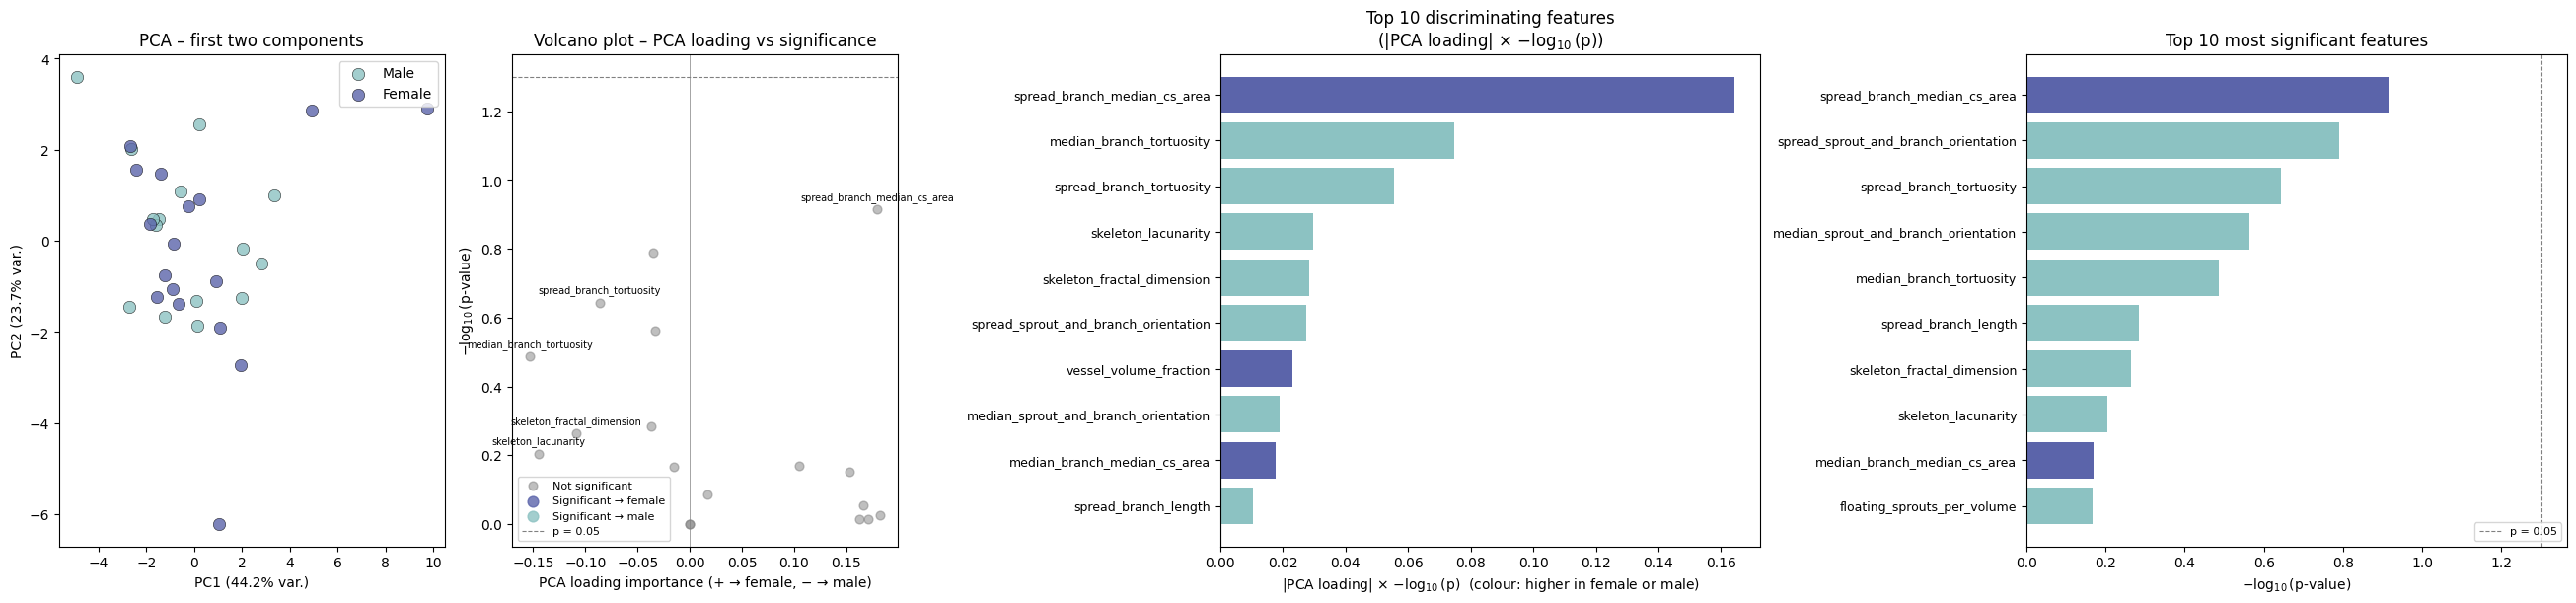

No significant features (p < 0.05). Returning top 5 most significant features (lowest p-values) instead.


In [15]:
significant_params, top_params = pca_plots(
    combined_analysis_metrics.drop(["name"], axis=1),
    CONDITION_COLORS, save_dir=output_dir, save_type="pdf"
)

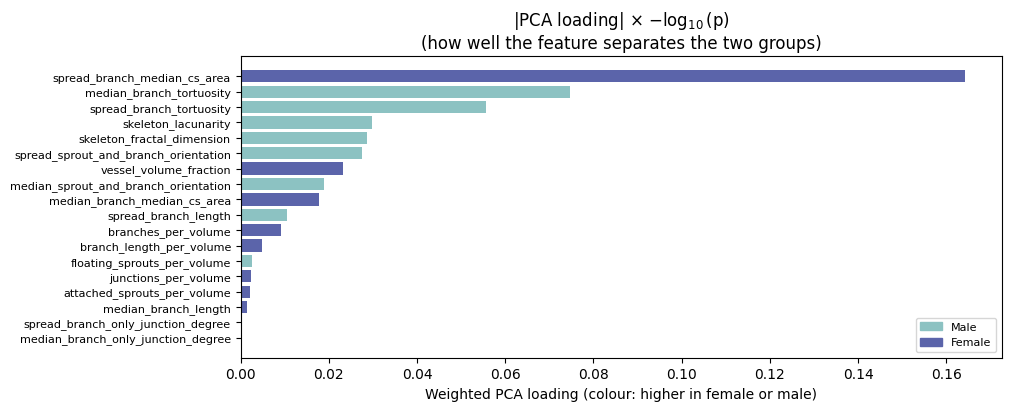

In [16]:
all_feature_discrim = plot_all_feature_discrimination(
    combined_analysis_metrics.drop(["name"], axis=1),
    CONDITION_COLORS, save_dir=output_dir, save_type="pdf"
)


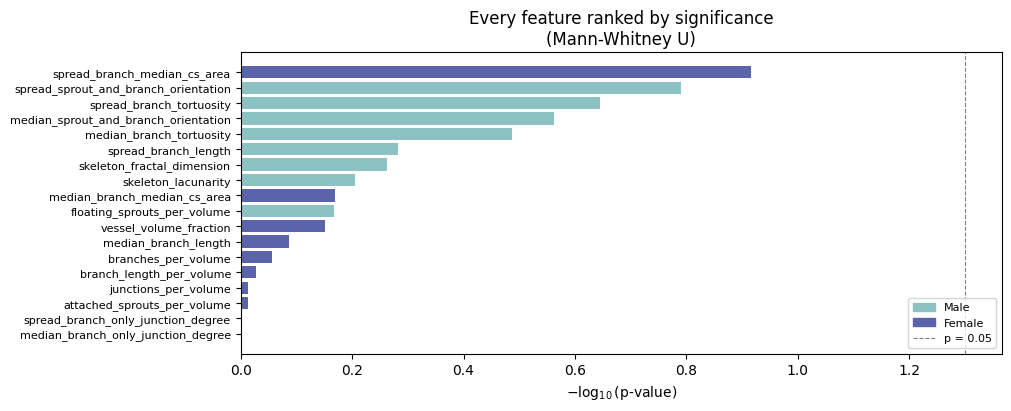

In [17]:
all_feature_sig = plot_all_feature_significance(
    combined_analysis_metrics.drop(["name"], axis=1),
    CONDITION_COLORS, save_dir=output_dir, save_type="pdf"
)


Saved: Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\New_Vascumap\Analyse_output_data\significant_changes.pdf


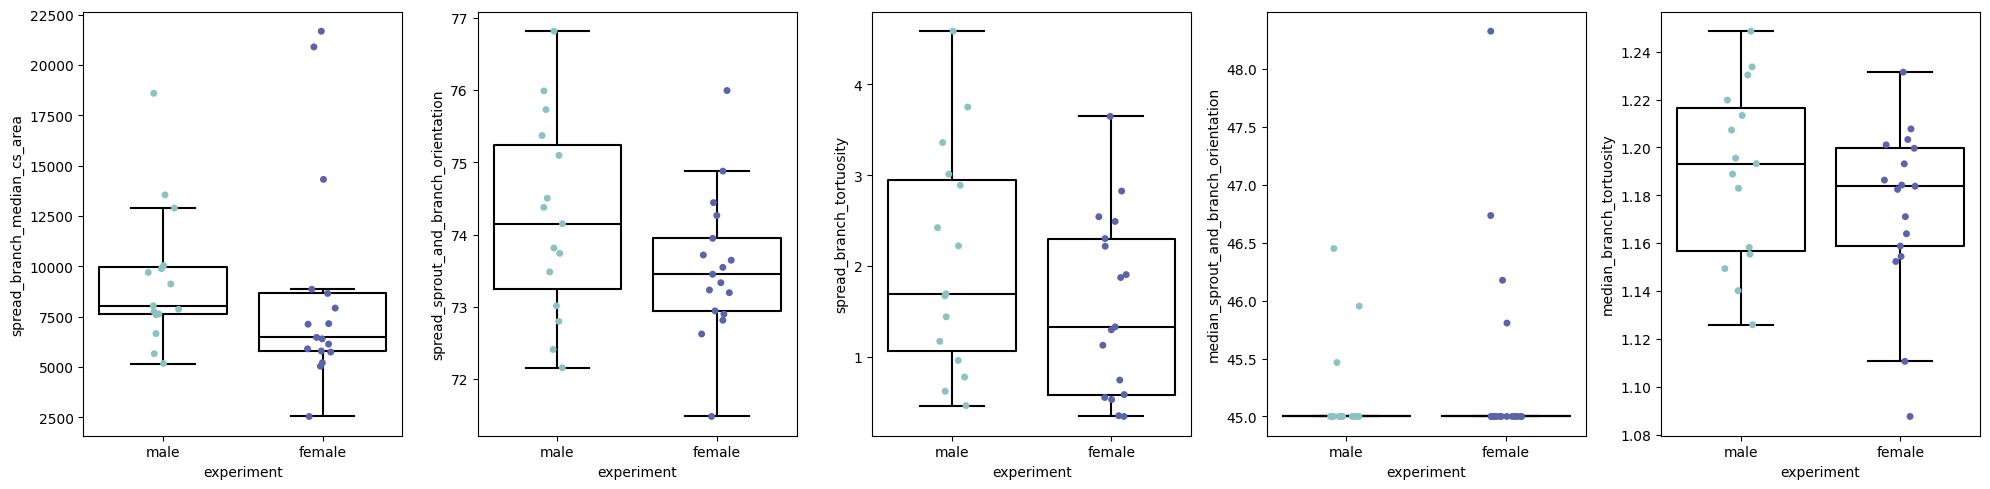

In [18]:
xorder = [c for c in CONDITION_COLORS if c in combined_analysis_metrics["experiment"].unique()]
plot_experiment_comparisons(
    combined_analysis_metrics,
    significant_params[:5], xorder, "significant_changes", output_dir, CONDITION_COLORS, save_type="pdf"
)

In [20]:
combined_analysis_metrics.columns

Index(['image_name', 'source_file', 'image_index', 'vessel_volume_fraction',
       'branch_length_per_volume', 'attached_sprouts_per_volume',
       'junctions_per_volume', 'branches_per_volume',
       'skeleton_fractal_dimension', 'skeleton_lacunarity',
       'median_branch_length', 'spread_branch_length',
       'median_branch_median_cs_area', 'spread_branch_median_cs_area',
       'median_branch_tortuosity', 'spread_branch_tortuosity',
       'median_branch_only_junction_degree',
       'spread_branch_only_junction_degree',
       'median_sprout_and_branch_orientation',
       'spread_sprout_and_branch_orientation', 'floating_sprouts_per_volume',
       'source_folder', 'name', 'experiment'],
      dtype='object')

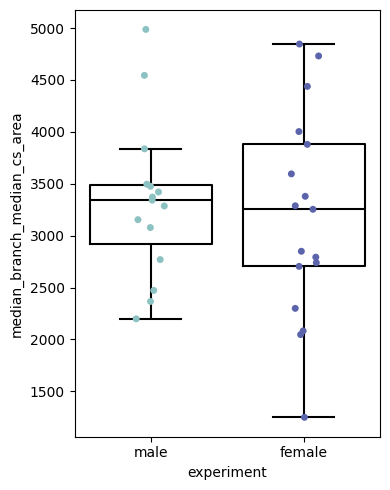

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

metric = "median_branch_median_cs_area"
xorder = [c for c in CONDITION_COLORS if c in combined_analysis_metrics["experiment"].unique()]
out_path = output_dir / f"{metric}_by_experiment.pdf"

fig, ax = plt.subplots(figsize=(4, 5))
sns.stripplot(data=combined_analysis_metrics, x="experiment", y=metric, ax=ax, zorder=100,
              hue="experiment", palette=CONDITION_COLORS, order=xorder, legend=False)
sns.boxplot(data=combined_analysis_metrics, x="experiment", y=metric, ax=ax,
            fill=False, color="#000000", order=xorder, showfliers=False)
plt.tight_layout()
fig.savefig(out_path, dpi=150, bbox_inches="tight")

